In [1]:
import pandas as pd
import joblib
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load cleaned dataset
df = pd.read_csv("../data/cleaned_data.csv")

# Check columns
print("Columns in dataset:", df.columns)

# Replace NaNs and ensure string type for text
text_col = "clean_statement"  
label_col = "status"           

df[text_col] = df[text_col].fillna("").astype(str)
df[label_col] = df[label_col].fillna("").astype(str)

X_text = df[text_col]
y = df[label_col]

print("Sample data:")
print(df.head())


Columns in dataset: Index(['Unnamed: 0', 'statement', 'status', 'statement_length',
       'clean_statement'],
      dtype='object')
Sample data:
   Unnamed: 0                                          statement   status  \
0           0                                         oh my gosh  Anxiety   
1           1  trouble sleeping, confused mind, restless hear...  Anxiety   
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety   
3           3  I've shifted my focus to something else but I'...  Anxiety   
4           4  I'm restless and restless, it's been a month n...  Anxiety   

   statement_length                                    clean_statement  
0                10                                            oh gosh  
1                64  trouble sleeping confused mind restless heart ...  
2                78  wrong back dear forward doubt stay restless re...  
3                61  ive shifted focus something else im still worried  
4                72       

In [4]:
# Load TF-IDF vectorizer
tfidf_path = "../models/vectorizer.pkl"
tfidf = joblib.load(tfidf_path)

# Transform text
X = tfidf.transform(X_text)
print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (52681, 5000)


Logistic Regression
                      precision    recall  f1-score   support

             Anxiety       0.85      0.82      0.83      3841
             Bipolar       0.90      0.78      0.83      2777
          Depression       0.76      0.78      0.77     15404
              Normal       0.86      0.96      0.91     16343
Personality disorder       0.89      0.57      0.69      1077
              Stress       0.81      0.55      0.66      2587
            Suicidal       0.74      0.70      0.72     10652

            accuracy                           0.81     52681
           macro avg       0.83      0.74      0.77     52681
        weighted avg       0.81      0.81      0.80     52681



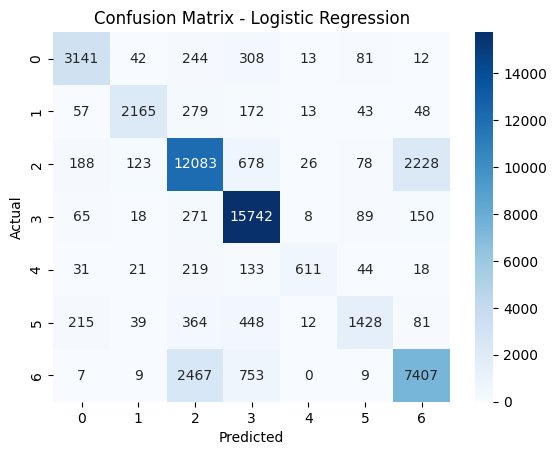

SVM
                      precision    recall  f1-score   support

             Anxiety       0.88      0.90      0.89      3841
             Bipolar       0.92      0.89      0.91      2777
          Depression       0.80      0.79      0.79     15404
              Normal       0.90      0.97      0.93     16343
Personality disorder       0.93      0.80      0.86      1077
              Stress       0.87      0.71      0.78      2587
            Suicidal       0.75      0.72      0.74     10652

            accuracy                           0.84     52681
           macro avg       0.86      0.83      0.84     52681
        weighted avg       0.84      0.84      0.84     52681



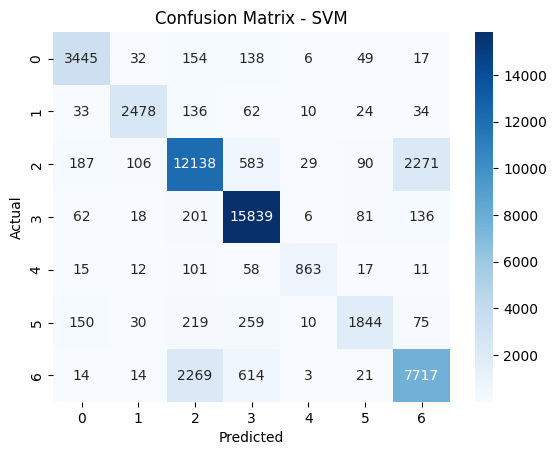

Naive Bayes
                      precision    recall  f1-score   support

             Anxiety       0.80      0.66      0.72      3841
             Bipolar       0.89      0.53      0.67      2777
          Depression       0.55      0.83      0.66     15404
              Normal       0.84      0.83      0.83     16343
Personality disorder       0.98      0.11      0.20      1077
              Stress       0.90      0.14      0.25      2587
            Suicidal       0.74      0.55      0.63     10652

            accuracy                           0.70     52681
           macro avg       0.81      0.52      0.57     52681
        weighted avg       0.74      0.70      0.68     52681



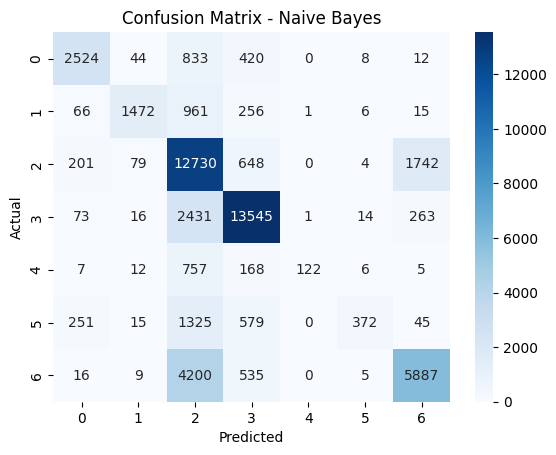

Random Forest
                      precision    recall  f1-score   support

             Anxiety       0.97      0.94      0.95      3841
             Bipolar       0.99      0.93      0.96      2777
          Depression       0.90      0.96      0.93     15404
              Normal       0.96      0.99      0.97     16343
Personality disorder       1.00      0.85      0.92      1077
              Stress       0.99      0.85      0.92      2587
            Suicidal       0.95      0.89      0.92     10652

            accuracy                           0.94     52681
           macro avg       0.97      0.92      0.94     52681
        weighted avg       0.94      0.94      0.94     52681



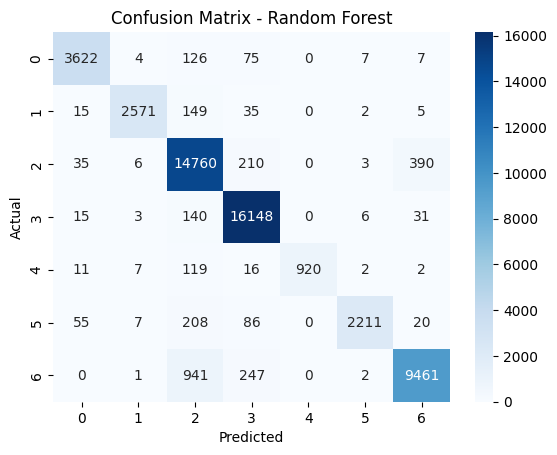


Best Model: Random Forest with weighted F1-score = 0.9430533845637085
Final model saved as: ../models/model.pkl


In [6]:
# Load trained models
model_paths = {
    "Logistic Regression": "../models/Logistic_Regression.pkl",
    "SVM": "../models/SVM.pkl",
    "Naive Bayes": "../models/Naive_Bayes.pkl",
    "Random Forest": "../models/Random_Forest.pkl"
}

models = {}
for name, path in model_paths.items():
    models[name] = joblib.load(path)

# Evaluate models
best_model = None
best_f1 = 0
best_name = ""

for name, model in models.items():
    print(name)
    preds = model.predict(X)
    
    # Classification report
    report = classification_report(y, preds)
    print(report)
    
    # Confusion matrix
    cm = confusion_matrix(y, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # Track best model by weighted F1-score
    report_dict = classification_report(y, preds, output_dict=True)
    f1 = report_dict["weighted avg"]["f1-score"]
    if f1 > best_f1:
        best_f1 = f1
        best_model = model
        best_name = name

print(f"\nBest Model: {best_name} with weighted F1-score = {best_f1}")

# Save final model
final_model_path = "../models/model.pkl"
joblib.dump(best_model, final_model_path)
print(f"Final model saved as: {final_model_path}")
